# Exploratory Data Analysis of Facial Emotion Recognition Dataset

This notebook consists of an exploratory data analysis  of the Facial Emotion Recognition dataset. The dataset is used for training machine learning models to recognize emotions from facial expressions.

Based on the information from [Kaggle](https://www.kaggle.com/datasets/msambare/fer2013)
The data consists of 48x48 pixel grayscale images of faces. The faces have been automatically registered so that the face is more or less centred and occupies about the same amount of space in each image.

The tasks is to categorize each face based on the emotion shown in the facial expression into one of seven categories (0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral). 
The training set consist of 28,709 examples and the public test set consist of 3,589 examples.
  
<img src="https://i.imgur.com/lA3PkYX.png">


## 1. Import and configuration

### Importing Libraries

In [1]:
import os
import zipfile
import random

import numpy as np
import pandas as pd

from dotenv import load_dotenv

from kaggle.api.kaggle_api_extended import KaggleApi

In [2]:
load_dotenv()

True

Defining constants

In [3]:
EMOTIONS = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

### Loading dataset

Initializing kaggle API

In [4]:
def download_and_extract_challenge_files(challenge_name: str, destination_path: str):
    api = KaggleApi()
    api.authenticate()

    api.competition_download_files(challenge_name, path=destination_path)

    for file in os.listdir(destination_path):
        file_path = os.path.join(destination_path, file)

        if zipfile.is_zipfile(file_path):
            with zipfile.ZipFile(file_path, 'r') as zip_ref:
                zip_ref.extractall(destination_path)
            os.remove(file_path)

In [5]:
def list_files_from_dir(directory_path: str):
    for root, _, files in os.walk(directory_path):
        for file in files:
            if file.endswith('.csv'): print(file)

In [6]:
challenge_name = 'challenges-in-representation-learning-facial-expression-recognition-challenge'
destination_path = '../data/external'

In [7]:
#download_and_extract_challenge_files(challenge_name, destination_path)

All files downloaded

In [8]:
list_files_from_dir(destination_path)

example_submission.csv
icml_face_data.csv
test.csv
train.csv


## 2. Preprocessing the dataset

Reading csv + first interaction with the dataset

In [9]:
df = pd.read_csv(f'{destination_path}/icml_face_data.csv')
df.head(10)

,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...
5,2,Training,55 55 55 55 55 54 60 68 54 85 151 163 170 179 ...
6,4,Training,20 17 19 21 25 38 42 42 46 54 56 62 63 66 82 1...
7,3,Training,77 78 79 79 78 75 60 55 47 48 58 73 77 79 57 5...
8,3,Training,85 84 90 121 101 102 133 153 153 169 177 189 1...
9,2,Training,255 254 255 254 254 179 122 107 95 124 149 150...


In [10]:
df.shape

(35887, 3)

Visualizing original train and test distribution

In [11]:
train_df = pd.read_csv(f'{destination_path}/train.csv')
train_df.shape

(28709, 2)

In [12]:
test_df = pd.read_csv(f'{destination_path}/test.csv')
test_df.shape

(7178, 1)

Renaming columns for better understanding

In [13]:
df.rename(columns={' pixels': 'pixels_str', ' Usage': 'usage'}, inplace=True)
df.columns

Index(['emotion', 'usage', 'pixels_str'], dtype='str')

Converting pixel values from string to numpy array

In [14]:
pixels_array = df['pixels_str'][0]
pixels_array

'70 80 82 72 58 58 60 63 54 58 60 48 89 115 121 119 115 110 98 91 84 84 90 99 110 126 143 153 158 171 169 172 169 165 129 110 113 107 95 79 66 62 56 57 61 52 43 41 65 61 58 57 56 69 75 70 65 56 54 105 146 154 151 151 155 155 150 147 147 148 152 158 164 172 177 182 186 189 188 190 188 180 167 116 95 103 97 77 72 62 55 58 54 56 52 44 50 43 54 64 63 71 68 64 52 66 119 156 161 164 163 164 167 168 170 174 175 176 178 179 183 187 190 195 197 198 197 198 195 191 190 145 86 100 90 65 57 60 54 51 41 49 56 47 38 44 63 55 46 52 54 55 83 138 157 158 165 168 172 171 173 176 179 179 180 182 185 187 189 189 192 197 200 199 196 198 200 198 197 177 91 87 96 58 58 59 51 42 37 41 47 45 37 35 36 30 41 47 59 94 141 159 161 161 164 170 171 172 176 178 179 182 183 183 187 189 192 192 194 195 200 200 199 199 200 201 197 193 111 71 108 69 55 61 51 42 43 56 54 44 24 29 31 45 61 72 100 136 150 159 163 162 163 170 172 171 174 177 177 180 187 186 187 189 192 192 194 195 196 197 199 200 201 200 197 201 137 58 98 92

In [15]:
number_array = np.array(list(map(int, pixels_array.split())))
number_array

array([ 70,  80,  82, ..., 106, 109,  82], shape=(2304,))

In [16]:
print(number_array.shape)

(2304,)


In [17]:
img = number_array.reshape(48, 48)
img

array([[ 70,  80,  82, ...,  52,  43,  41],
       [ 65,  61,  58, ...,  56,  52,  44],
       [ 50,  43,  54, ...,  49,  56,  47],
       ...,
       [ 91,  65,  42, ...,  72,  56,  43],
       [ 77,  82,  79, ..., 105,  70,  46],
       [ 77,  72,  84, ..., 106, 109,  82]], shape=(48, 48))

Applying the function to convert the 'pixels' column to numpy arrays

In [18]:
def converting_pixels_to_numpy_array(pixels_string: str) -> np.ndarray:
    return np.array(list(map(int, pixels_string.split()))).reshape(48, 48)

def converting_pixels_column_to_numpy_array(df: pd.DataFrame) -> pd.DataFrame:
    df['pixels'] = df['pixels_str'].apply(converting_pixels_to_numpy_array)
    return df

df = converting_pixels_column_to_numpy_array(df)
df.head()

,emotion,usage,pixels_str,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,"[[70, 80, 82, 72, 58, 58, 60, 63, 54, 58, 60, ..."
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...,"[[151, 150, 147, 155, 148, 133, 111, 140, 170,..."
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...,"[[231, 212, 156, 164, 174, 138, 161, 173, 182,..."
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,"[[24, 32, 36, 30, 32, 23, 19, 20, 30, 41, 21, ..."
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,"[[4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 15, 2..."


## 3. Exploratory Data Analysis

Ploting first samples of the dataset

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

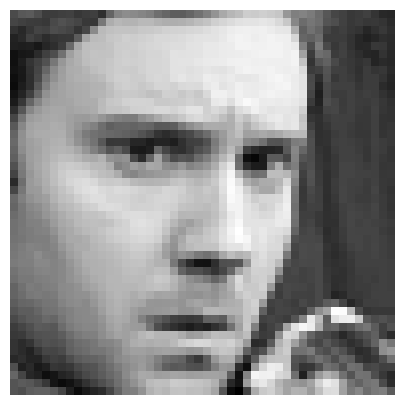

In [20]:
plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

Visualizing samples of each emotion category

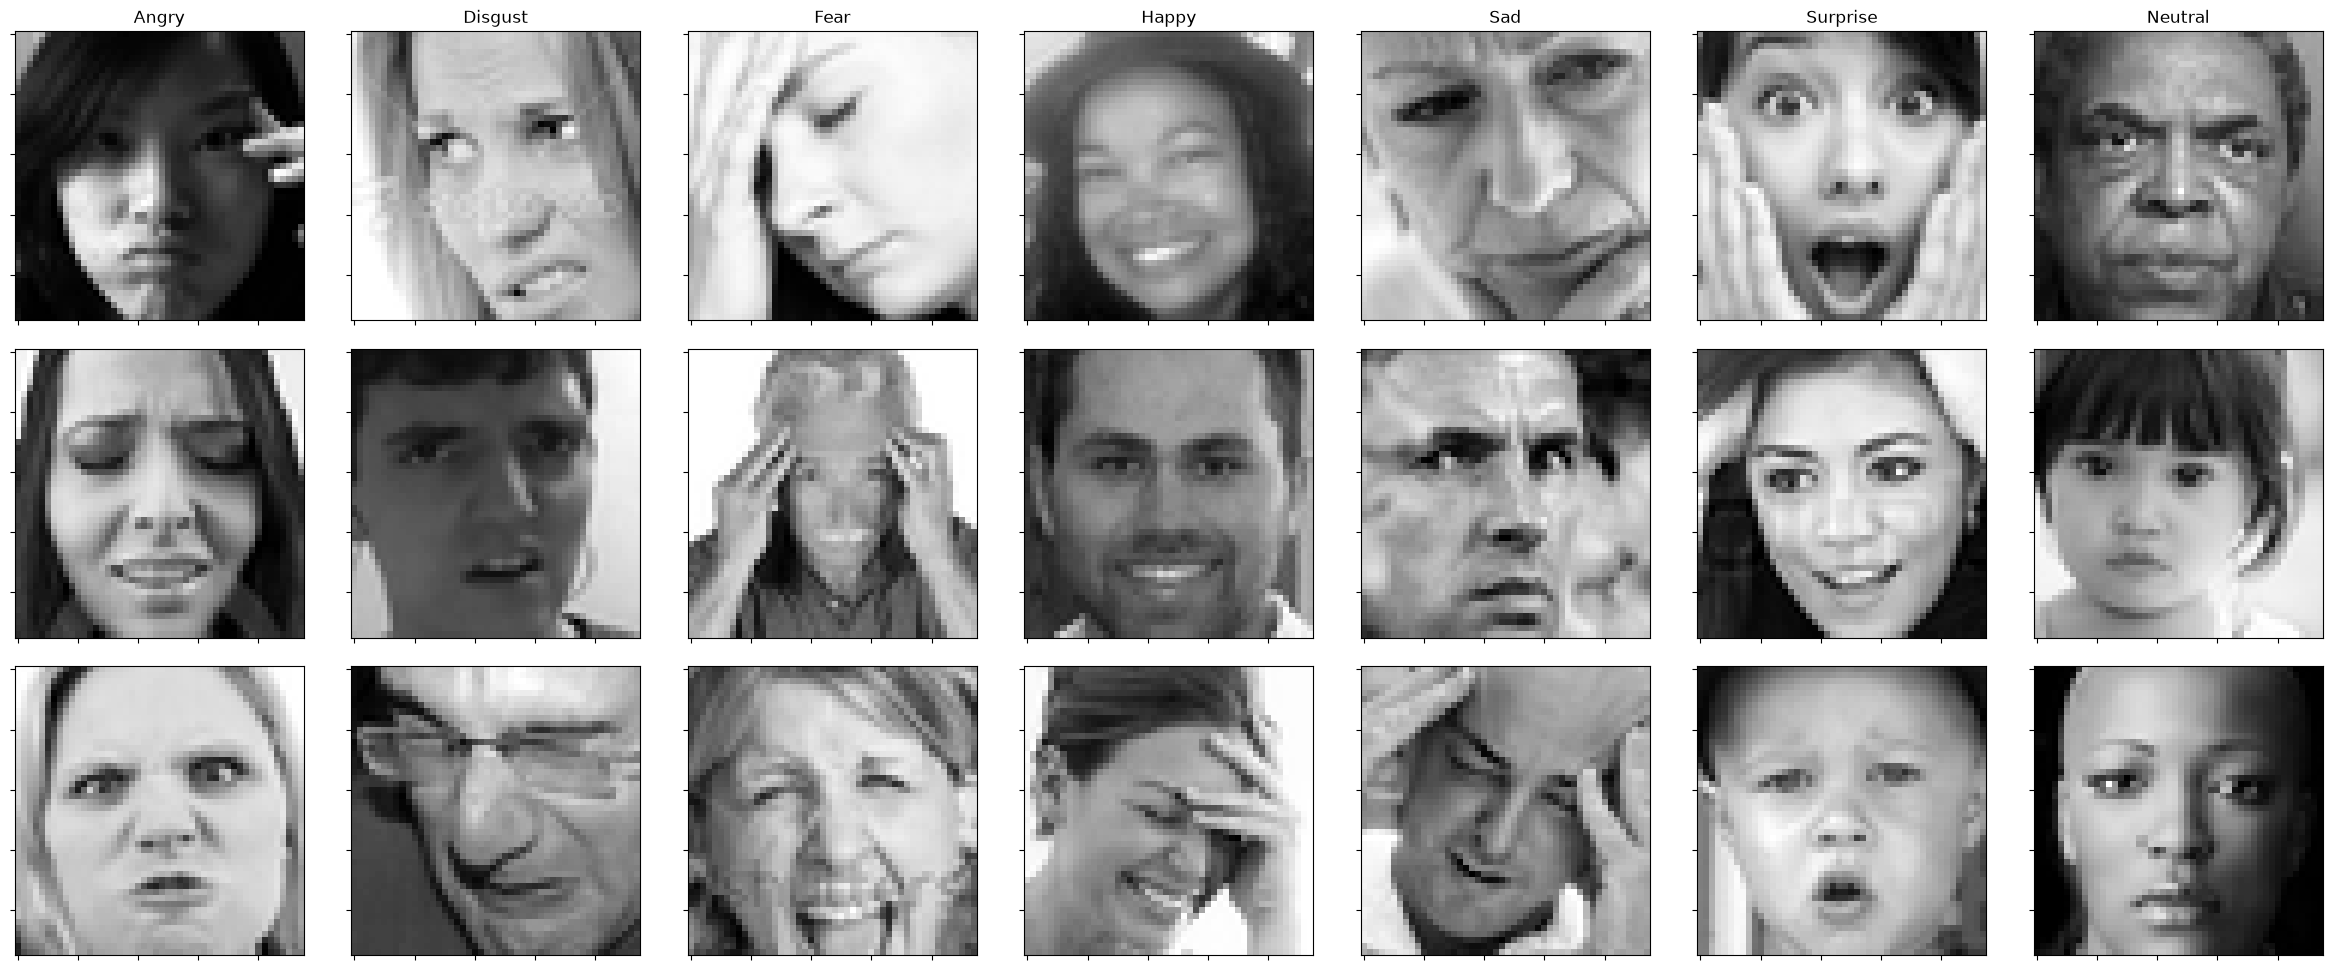

In [21]:
def show_samples(amount):
    fig, axs = plt.subplots(3, 7, figsize=(30, 12))
    fig.subplots_adjust(hspace=0.1, wspace=0.1)
    axs = axs.ravel()

    n_emotion = len(EMOTIONS.items())

    for j in range(amount):
        for i in range(n_emotion):
            random_number = random.randint(0, 100)
            idx = df[df['emotion'] == i].index[random_number]
            axs[j*n_emotion + i].imshow(df.iloc[idx]['pixels'], cmap='gray')
            axs[j*n_emotion + i].set_title(EMOTIONS[i] if j == 0 else '')
            axs[j*n_emotion + i].set_xticklabels([])
            axs[j*n_emotion + i].set_yticklabels([])

    plt.show()

show_samples(3)

Visualizing the distribution of emotions in the dataset

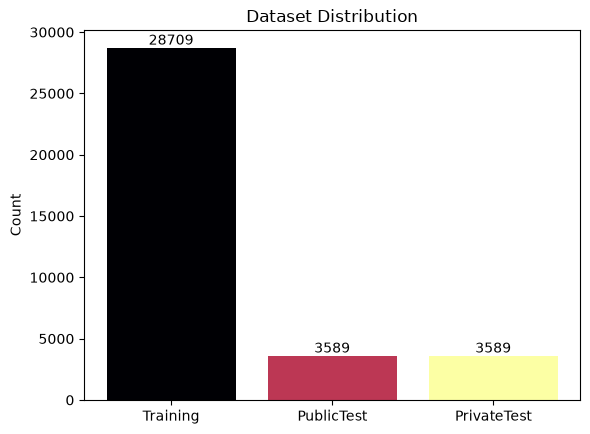

In [22]:
value_counts = df['usage'].value_counts()

cmap = plt.get_cmap('inferno', len(value_counts))
plt.bar(value_counts.index, value_counts.values, color=[cmap(i) for i in range(len(value_counts))])
plt.ylabel('Count')
plt.title('Dataset Distribution')

for i, v in enumerate(value_counts.values):
  plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

Visualizing samples from each category of emotion

In [23]:
def show_sample_by_category(label=0):
    fig, axs = plt.subplots(1, 5, figsize=(25, 12))
    fig.subplots_adjust(hspace=0.2, wspace=0.2)

    for i, ax in enumerate(axs):
        idx = df[df['emotion']==label].index[i + random.randint(0, 100)]
        ax.imshow(df.iloc[idx]['pixels'], cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()

Samples from Angry Category

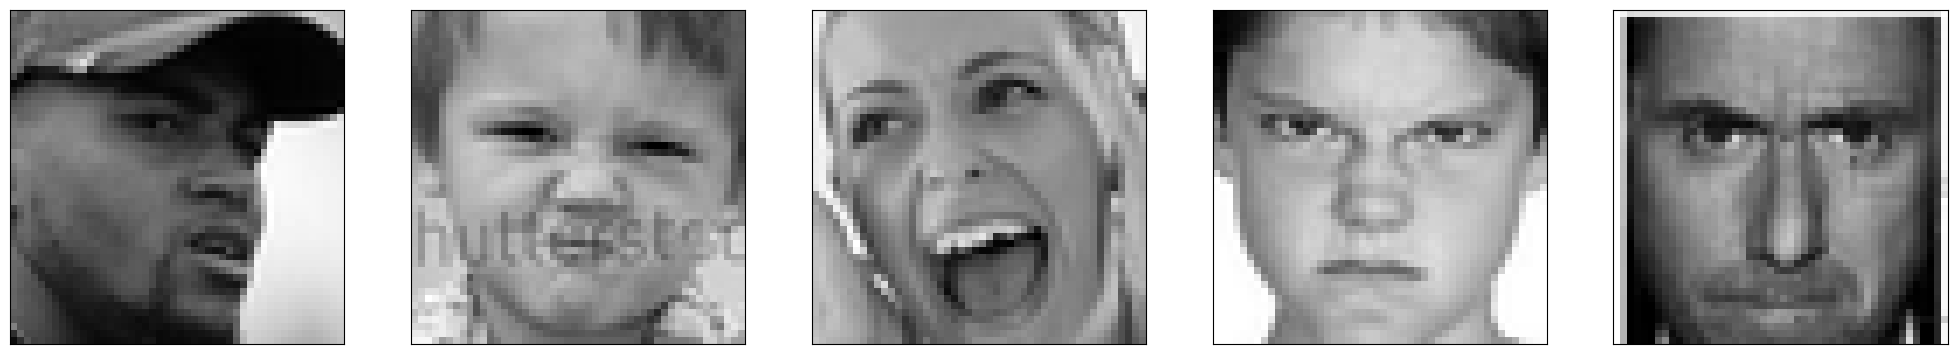

In [24]:
show_sample_by_category(0)

Samples from Disgust Category

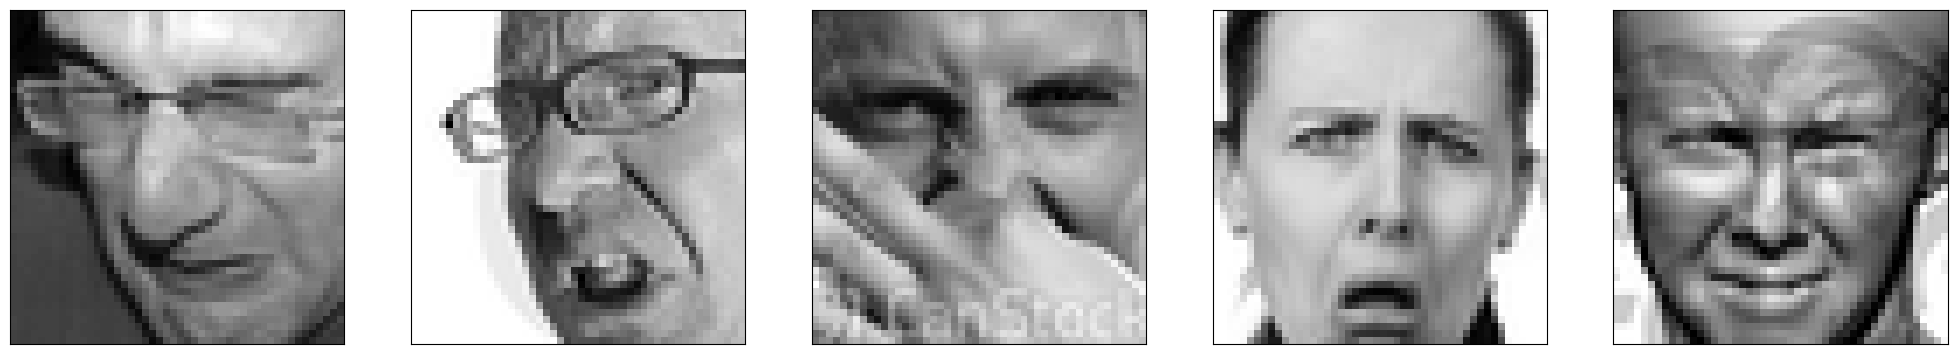

In [25]:
show_sample_by_category(1)

Samples from Fear Category

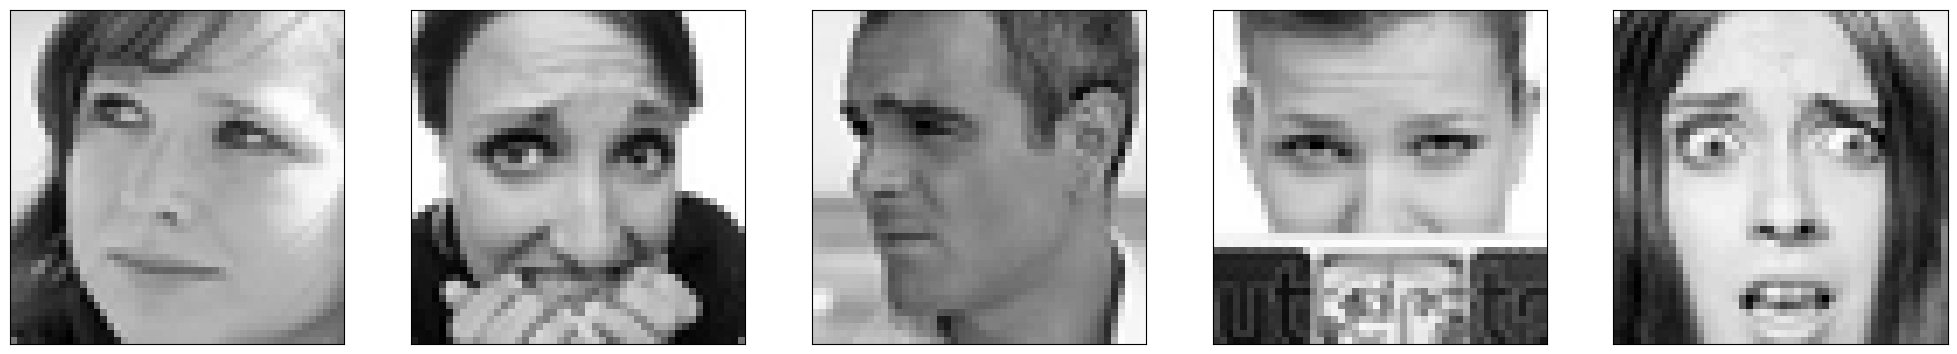

In [26]:
show_sample_by_category(2)

Samples from Happy Category

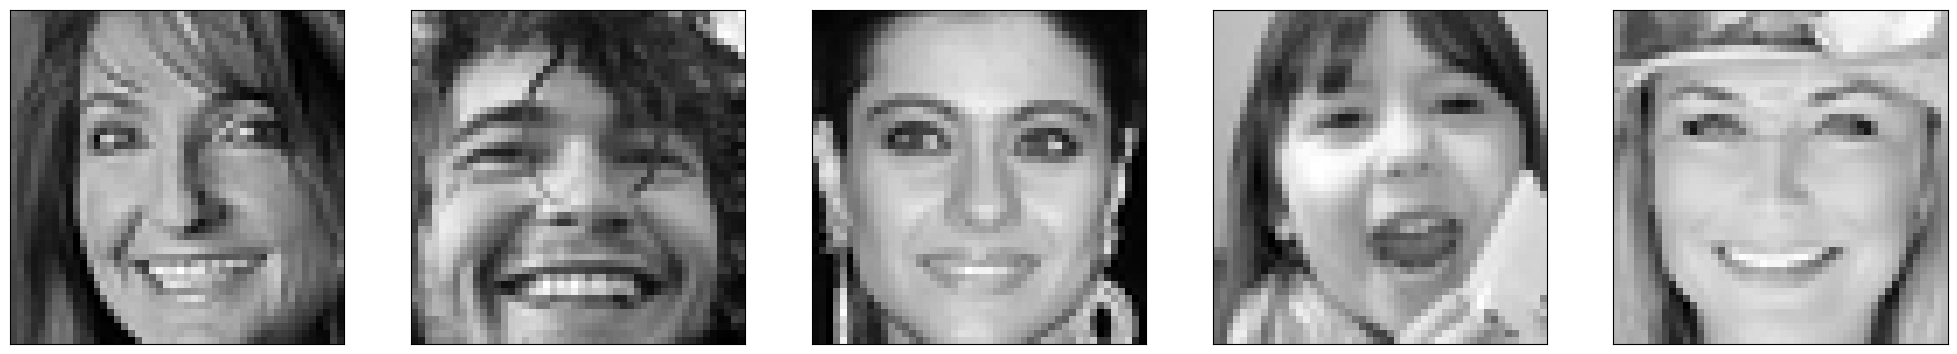

In [27]:
show_sample_by_category(3)

Samples from Sad Category

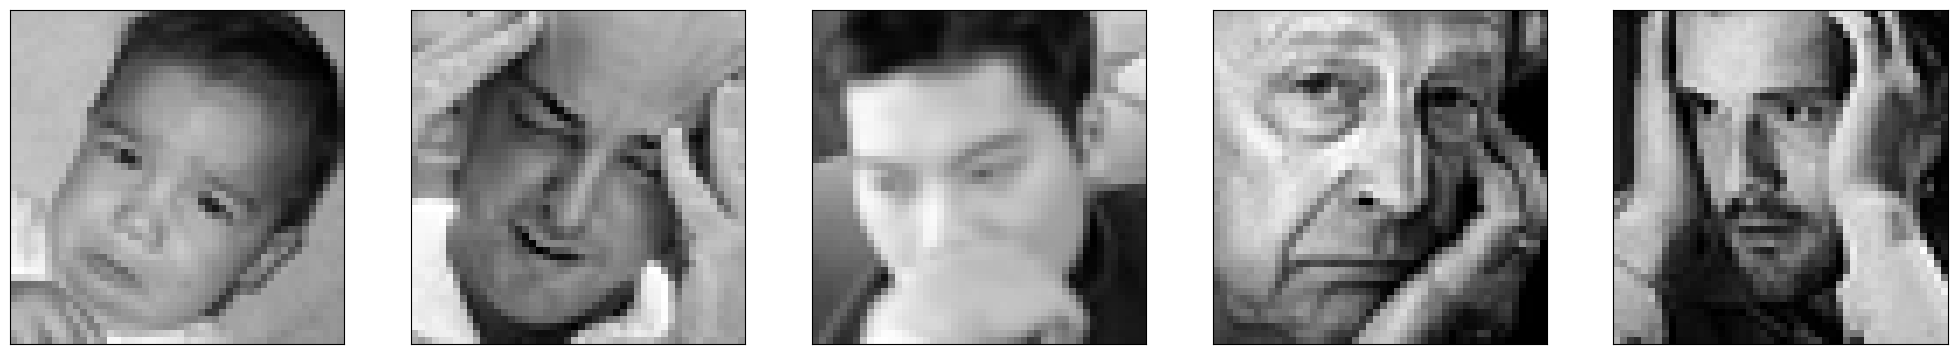

In [28]:
show_sample_by_category(4)

Samples from Surprised Category

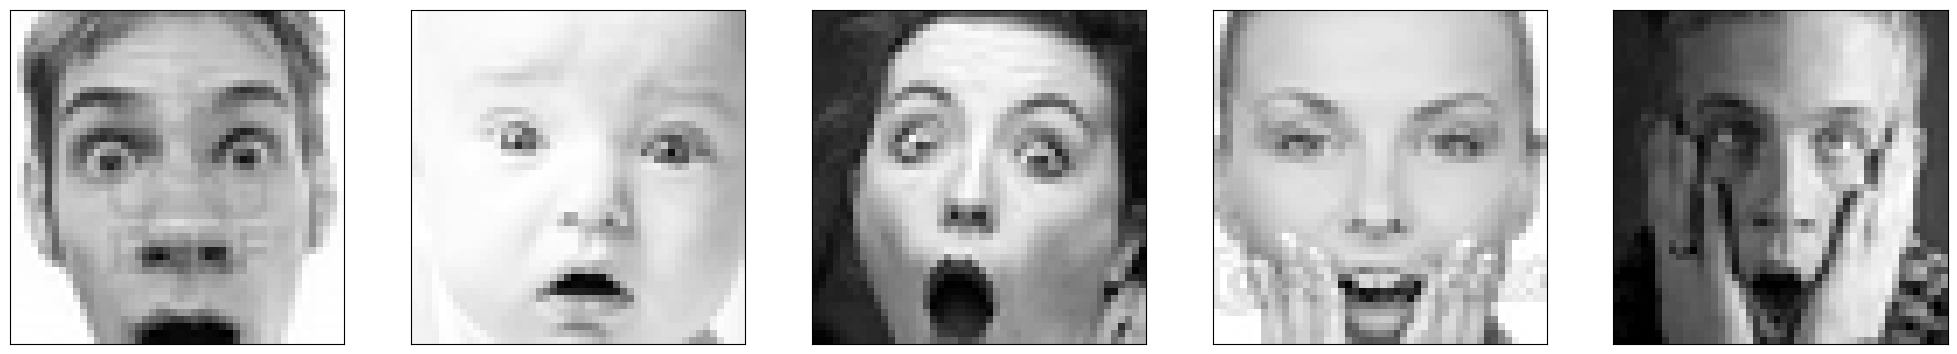

In [29]:
show_sample_by_category(5)

Samples from Neutral Category

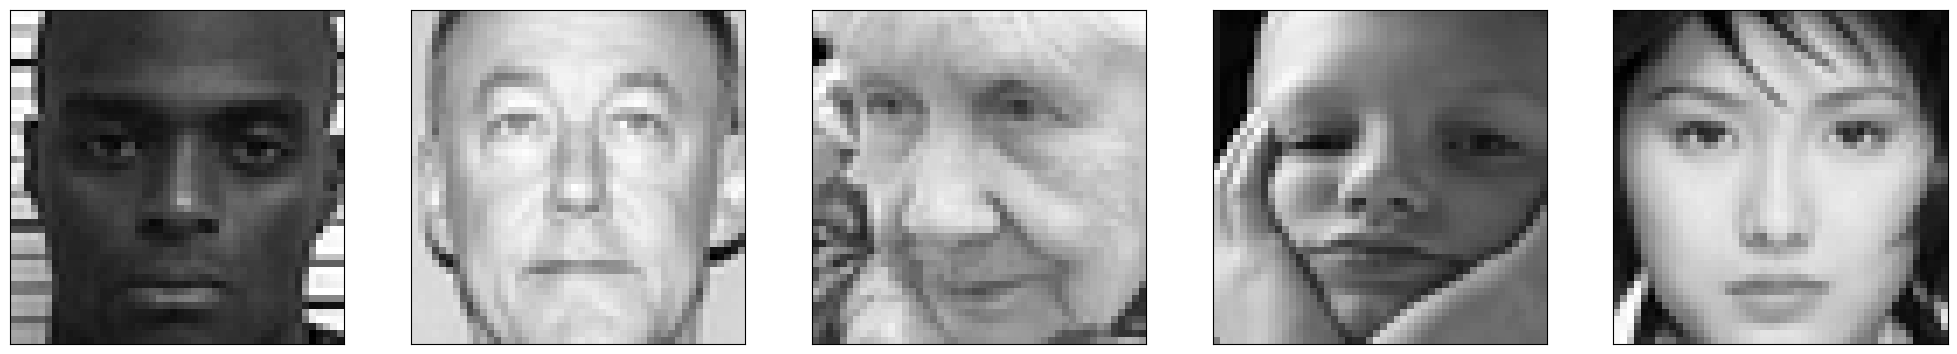

In [30]:
show_sample_by_category(6)

In [31]:
def plot_emotion_distribution(df: pd.DataFrame, title: str, axs: plt.Axes, color_map_str: str):
    x = EMOTIONS.values()
    y = df['emotion'].value_counts()

    color_map = plt.get_cmap(color_map_str, len(y.values))
    color_map = [color_map(i) for i in sorted(range(len(y.values)), reverse=True)]

    bars = axs.bar(x, y.values, color=color_map)
    axs.bar_label(bars, rotation=90, padding=3, labels=y.values)
    axs.set_title(title)
    axs.set_ylabel('Count')
    axs.tick_params(axis="x", labelrotation=90)
    axs.grid()

def compare_dataset_distribution(df: pd.DataFrame):
    _, axs = plt.subplots(1, 3, figsize=(12, 6), sharey=False)

    plot_emotion_distribution(df[df['usage'] == 'Training'], 'Training', axs[0], 'Reds')
    plot_emotion_distribution(df[df['usage'] == 'PublicTest'], 'Validation', axs[1], 'Greens')
    plot_emotion_distribution(df[df['usage'] == 'PrivateTest'], 'Test', axs[2], 'Blues')

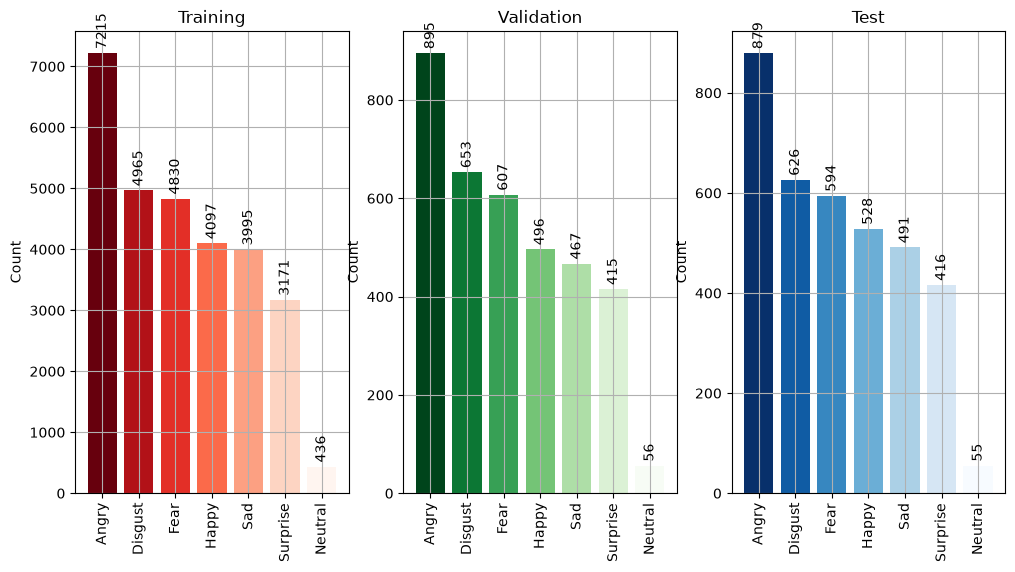

In [32]:
compare_dataset_distribution(df)

### Removing Duplicateds

Verifying count of duplicated images based on pixel values from different categories or sets (train/val/test)

creating hash values for each image in the dataset

In [33]:
import uuid

In [34]:
df['hash'] = df['pixels_str'].apply(lambda x: uuid.uuid5(uuid.NAMESPACE_DNS, x).hex)
df['hash']

0        379c6be0affc51488b7177ed1ba8ac4c
1        914f4c89d45750cfb140c42040ed723f
2        34e0366997775b2d85ca2b374a70b663
3        9853b3a6e49a5dd0ac9a8b5d9f9f3470
4        ce1d4c28cfff5df696c3d526905089a0
                       ...               
35882    0b8def38e93d5a0185d5a6be5187ee2a
35883    aea9c383e3ed5ff08c25b0cfd5ecc060
35884    6f8e8f5f8d25522f82bd35e156b882d3
35885    5e8c714088bf57228ad6378efa5611f3
35886    be2c442da7695a9f9da99e88897c6897
Name: hash, Length: 35887, dtype: str

amount of duplicated images in the dataset based on pixel values

In [35]:
df['hash'].duplicated().sum()

np.int64(1853)

Quantity of duplicated images on different sets

In [36]:
(df.groupby('hash')['usage'].nunique() > 1).sum()

np.int64(557)

In [37]:
(df.groupby('hash')['usage'].nunique() > 1)

hash
0000347d56b057139910cf90d130929e    False
00023a99d98b53789ebe931f397d3fba    False
0002c6c109e05e8d98fccf307ad5dce8    False
0003ba2544ac519cb446d42e4823df94    False
00054199765c533496aa9f0a20d4bf50    False
                                    ...  
fff7cf3a226256d2bd16e466fd2a6412    False
fff7da4d46c25baa910b85f51a65d3de     True
fff8ca84164053f8beef41998ff3b797    False
fff9511642af55969136e385dc9d2543    False
fffc0678b41853d695208ffebe24b074    False
Name: usage, Length: 34034, dtype: bool

In [38]:
usage_combinations = (
    df.groupby('hash')['usage']
    .apply(lambda s: tuple(sorted(s.unique())))
)

combination_counts = usage_combinations.value_counts()
combination_counts

usage
(Training,)                            26942
(PrivateTest,)                          3268
(PublicTest,)                           3267
(PrivateTest, Training)                  261
(PublicTest, Training)                   253
(PrivateTest, PublicTest)                 26
(PrivateTest, PublicTest, Training)       17
Name: count, dtype: int64

Identifying images from Training where exists in others sets (val or test).

The mindset is to keep as much as possible in the Validation and Test by the reason they have fewer amount of images

In [39]:
hashes_to_drop_from_train = usage_combinations[
    usage_combinations.apply(lambda combo: 'Training' in combo and len(combo) > 1)
]
hashes_to_drop_from_train

hash
0158b7b708ab5e6d8f2c3972e73a32ad    (PrivateTest, Training)
016f8f9227245052b430a39b45e36452    (PrivateTest, Training)
018b42e1c9f95da09e7edc5adcf6aea6    (PrivateTest, Training)
01d8a33439e15901b15993dbac658871     (PublicTest, Training)
03189ebbdbe65ba38989ff6f025aac9d     (PublicTest, Training)
                                             ...           
fe311c43448e5f2eb1fb58ca1bf989f9    (PrivateTest, Training)
fe8e743a9b0858968818f55523cceb9d     (PublicTest, Training)
fea9555ff64e5d8285f43b04766e4bb8     (PublicTest, Training)
ff805f92be77537f8c3c4f1482b2998b    (PrivateTest, Training)
fff7da4d46c25baa910b85f51a65d3de    (PrivateTest, Training)
Name: usage, Length: 531, dtype: object

Rows to drop based on duplicates

In [40]:
df[(
    (
        df['hash'].isin(hashes_to_drop_from_train.index)
    ) &
    (
        df['usage'] == 'Training'
    )
)]

,emotion,usage,pixels_str,pixels,hash
78,5,Training,33 31 34 34 31 33 33 33 36 25 53 104 38 21 29 ...,"[[33, 31, 34, 34, 31, 33, 33, 33, 36, 25, 53, ...",222a52664fa75a02b221c1bf787ff401
81,5,Training,253 200 93 92 93 64 62 92 106 103 88 36 34 54 ...,"[[253, 200, 93, 92, 93, 64, 62, 92, 106, 103, ...",a8aa01da6cb25c33891b0c6e95f7fee0
120,0,Training,254 253 253 245 215 175 179 137 62 29 25 50 11...,"[[254, 253, 253, 245, 215, 175, 179, 137, 62, ...",6779ca0775bf579f8e4c442894e3da89
157,0,Training,254 253 252 255 227 83 50 49 38 41 43 36 57 14...,"[[254, 253, 252, 255, 227, 83, 50, 49, 38, 41,...",825177dcde8a57f1aaa43478433b64dc
158,2,Training,155 142 153 161 154 144 153 165 155 159 159 16...,"[[155, 142, 153, 161, 154, 144, 153, 165, 155,...",1b7982ff329a5691a4c7197b0c73a004
...,...,...,...,...,...
28448,5,Training,255 255 255 254 254 252 174 59 35 34 40 57 84 ...,"[[255, 255, 255, 254, 254, 252, 174, 59, 35, 3...",10451e4fcb14512abddb37afce41b142
28476,5,Training,254 254 252 255 214 34 63 138 155 157 159 167 ...,"[[254, 254, 252, 255, 214, 34, 63, 138, 155, 1...",763d771f30465a8394266eaf820e23b1
28544,5,Training,20 22 23 29 44 122 141 114 81 84 100 130 117 1...,"[[20, 22, 23, 29, 44, 122, 141, 114, 81, 84, 1...",8c88d50ec135520680f60a7f63a60779
28601,0,Training,0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",bca873edb2bf52edba411f271b85f0e1


Cleaning the dataset

In [41]:
df = df[~((df['hash'].isin(hashes_to_drop_from_train.index)) & (df['usage'] == 'Training'))]
df

,emotion,usage,pixels_str,pixels,hash
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,"[[70, 80, 82, 72, 58, 58, 60, 63, 54, 58, 60, ...",379c6be0affc51488b7177ed1ba8ac4c
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...,"[[151, 150, 147, 155, 148, 133, 111, 140, 170,...",914f4c89d45750cfb140c42040ed723f
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...,"[[231, 212, 156, 164, 174, 138, 161, 173, 182,...",34e0366997775b2d85ca2b374a70b663
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,"[[24, 32, 36, 30, 32, 23, 19, 20, 30, 41, 21, ...",9853b3a6e49a5dd0ac9a8b5d9f9f3470
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,"[[4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 15, 2...",ce1d4c28cfff5df696c3d526905089a0
...,...,...,...,...,...
35882,6,PrivateTest,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,"[[50, 36, 17, 22, 23, 29, 33, 39, 34, 37, 37, ...",0b8def38e93d5a0185d5a6be5187ee2a
35883,3,PrivateTest,178 174 172 173 181 188 191 194 196 199 200 20...,"[[178, 174, 172, 173, 181, 188, 191, 194, 196,...",aea9c383e3ed5ff08c25b0cfd5ecc060
35884,0,PrivateTest,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,"[[17, 17, 16, 23, 28, 22, 19, 17, 25, 26, 20, ...",6f8e8f5f8d25522f82bd35e156b882d3
35885,3,PrivateTest,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,"[[30, 28, 28, 29, 31, 30, 42, 68, 79, 81, 77, ...",5e8c714088bf57228ad6378efa5611f3


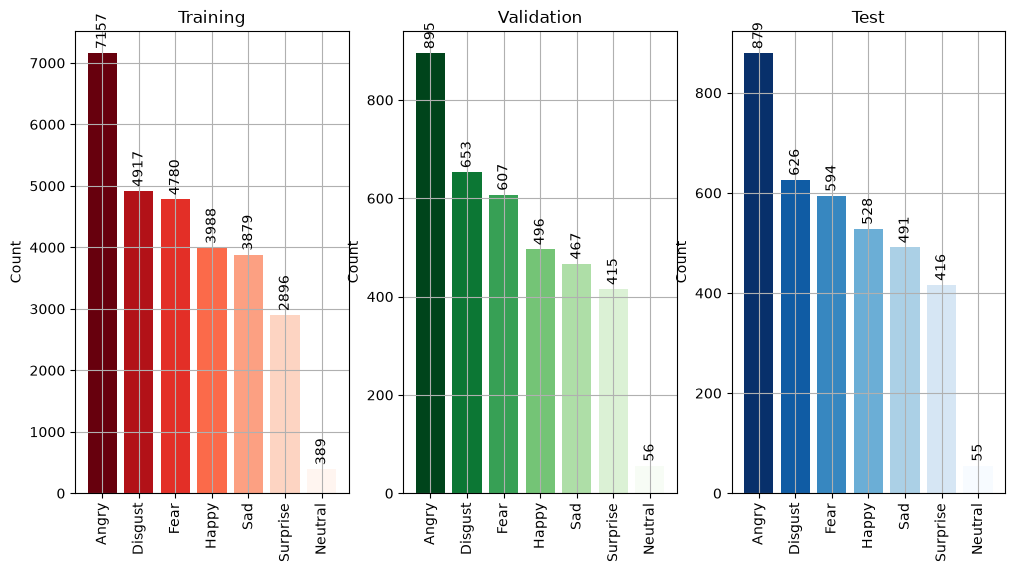

In [42]:
compare_dataset_distribution(df)

**Verifying duplicates based on similar image pixels from different sets**

computing perceptual hash

In [43]:
import imagehash
from PIL import Image

def compute_phash(pixels_str):
    array = np.array(list(map(int, pixels_str.split())), dtype=np.uint8).reshape(48, 48)
    return imagehash.phash(Image.fromarray(array))

df['phash'] = df['pixels_str'].apply(compute_phash)

In [44]:
hash_matrix = np.stack(df['phash'].apply(lambda h: h.hash.flatten()).values)
hash_matrix

array([[ True,  True, False, ..., False,  True,  True],
       [ True, False,  True, ...,  True,  True,  True],
       [ True,  True, False, ..., False, False, False],
       ...,
       [ True, False, False, ...,  True, False, False],
       [ True,  True, False, ...,  True, False,  True],
       [ True,  True, False, ..., False,  True,  True]], shape=(35184, 64))

In [45]:
hash_matrix.shape

(35184, 64)

In [46]:
from sklearn.neighbors import NearestNeighbors

threshold_bits = 5
n_bits = hash_matrix.shape[1]

nn = NearestNeighbors(metric='hamming', radius=threshold_bits / n_bits)
nn.fit(hash_matrix)
neighbor_indices = nn.radius_neighbors(hash_matrix, return_distance=False)
neighbor_indices

array([array([0]), array([1]), array([2]), ..., array([35181]),
       array([35182]), array([23109, 35183])],
      shape=(35184,), dtype=object)

In [47]:
neighbor_indices.shape

(35184,)

In [48]:
usage = df['usage'].values

cross_split_pairs = []
for i, neighbors in enumerate(neighbor_indices):
    for j in neighbors:
        if j > i and usage[i] != usage[j]:
            cross_split_pairs.append((i, j))

len(cross_split_pairs)

682

In [49]:
cross_split_pairs

[(21, np.int64(34980)),
 (29, np.int64(31028)),
 (29, np.int64(34141)),
 (49, np.int64(29177)),
 (70, np.int64(32813)),
 (107, np.int64(28498)),
 (203, np.int64(29733)),
 (248, np.int64(28082)),
 (248, np.int64(31258)),
 (357, np.int64(31706)),
 (375, np.int64(30016)),
 (494, np.int64(30248)),
 (581, np.int64(32786)),
 (636, np.int64(33533)),
 (649, np.int64(30011)),
 (677, np.int64(28832)),
 (689, np.int64(32394)),
 (746, np.int64(30842)),
 (754, np.int64(33854)),
 (813, np.int64(28890)),
 (843, np.int64(30863)),
 (930, np.int64(34373)),
 (952, np.int64(32348)),
 (1036, np.int64(31361)),
 (1071, np.int64(30577)),
 (1084, np.int64(34312)),
 (1132, np.int64(28610)),
 (1206, np.int64(28718)),
 (1206, np.int64(28959)),
 (1206, np.int64(33972)),
 (1218, np.int64(30577)),
 (1331, np.int64(30501)),
 (1331, np.int64(31988)),
 (1331, np.int64(34560)),
 (1338, np.int64(30892)),
 (1338, np.int64(34487)),
 (1397, np.int64(35179)),
 (1406, np.int64(34993)),
 (1424, np.int64(34157)),
 (1431, np.int

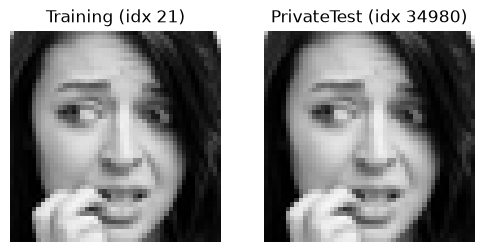

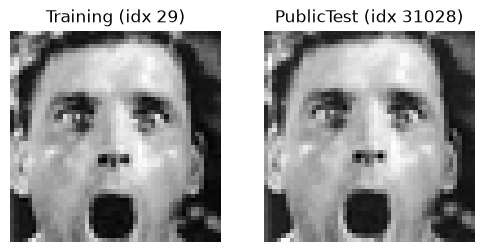

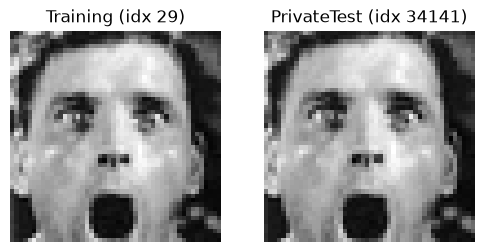

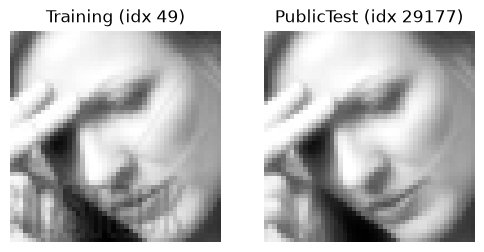

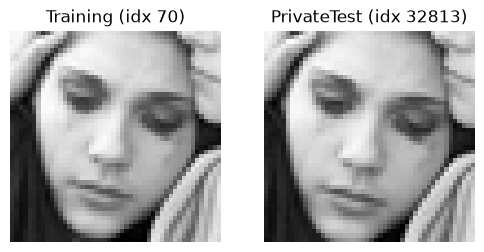

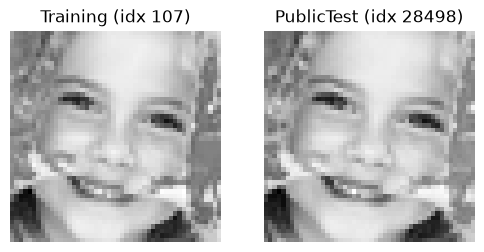

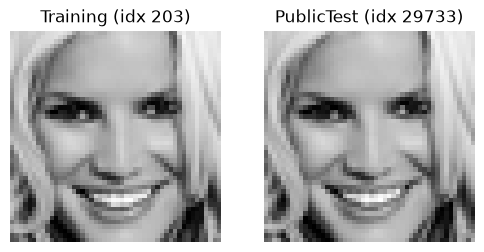

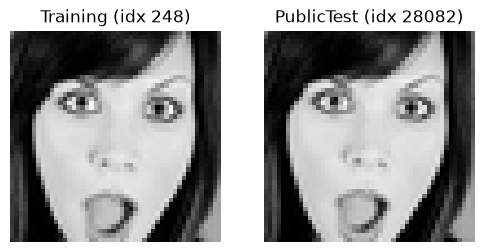

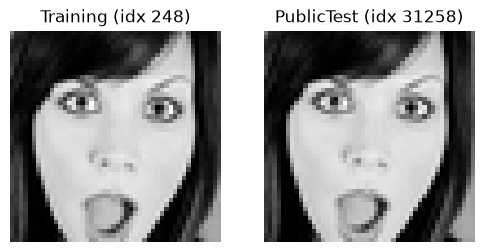

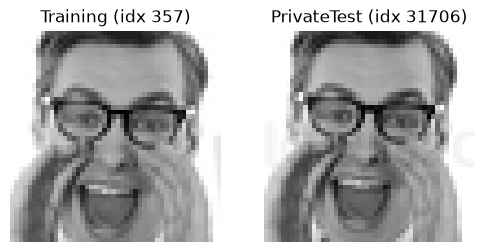

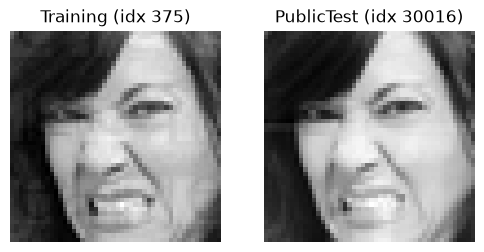

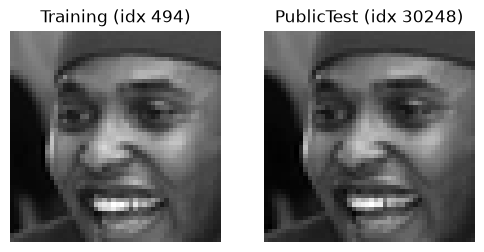

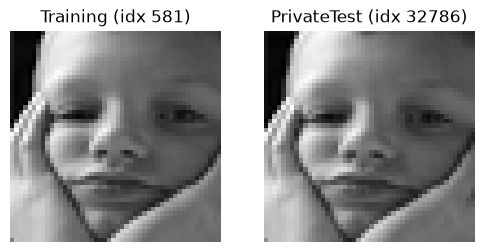

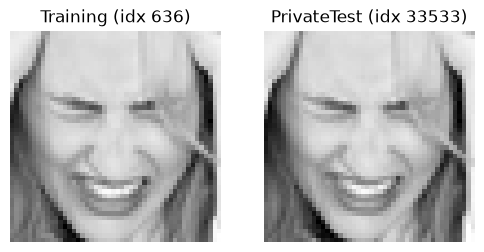

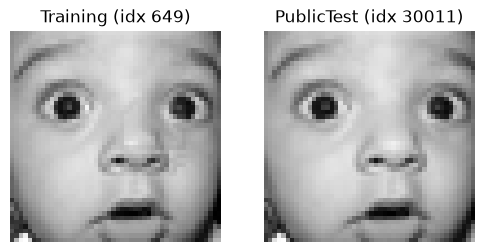

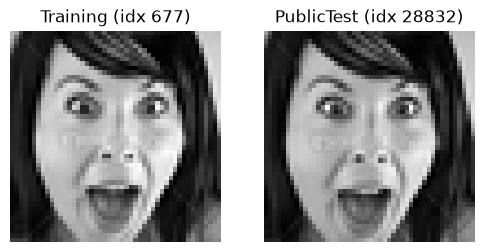

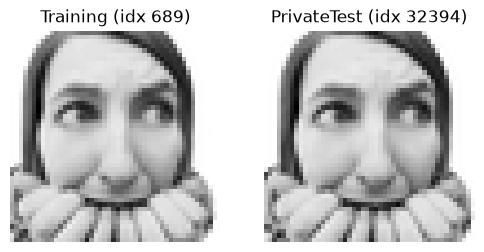

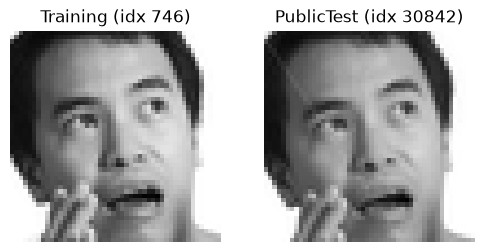

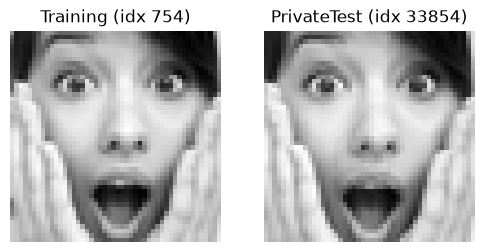

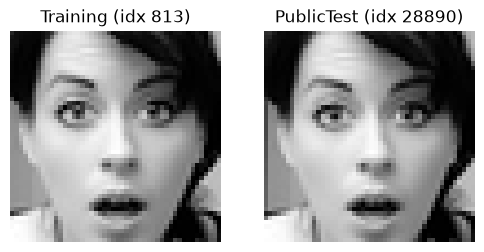

In [50]:
def plot_pair(i, j):
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))

    for ax, idx in zip(axs, (i, j)):
        row = df.iloc[idx]
        image = np.array(list(map(int, row['pixels_str'].split())), dtype=np.uint8).reshape(48, 48)
        ax.imshow(image, cmap='gray')
        ax.set_title(f"{row['usage']} (idx {idx})")
        ax.axis('off')

    plt.show()

for i, j in cross_split_pairs[:20]:
    plot_pair(i, j)

In [52]:
near_dup_train_idx = set()
for i, j in cross_split_pairs:
    if usage[i] == 'Training':
        near_dup_train_idx.add(i)
    if usage[j] == 'Training':
        near_dup_train_idx.add(j)

rows_to_drop = df.iloc[list(near_dup_train_idx)].index

before_count = (df['usage'] == 'Training').sum()

df = df.drop(index=rows_to_drop)
df

,emotion,usage,pixels_str,pixels,hash,phash
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,"[[70, 80, 82, 72, 58, 58, 60, 63, 54, 58, 60, ...",379c6be0affc51488b7177ed1ba8ac4c,d2d007c38e693f33
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...,"[[151, 150, 147, 155, 148, 133, 111, 140, 170,...",914f4c89d45750cfb140c42040ed723f,afd0cb8f9827e007
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...,"[[231, 212, 156, 164, 174, 138, 161, 173, 182,...",34e0366997775b2d85ca2b374a70b663,d515fede85683890
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,"[[24, 32, 36, 30, 32, 23, 19, 20, 30, 41, 21, ...",9853b3a6e49a5dd0ac9a8b5d9f9f3470,a5260c7993c4df96
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,"[[4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 15, 2...",ce1d4c28cfff5df696c3d526905089a0,93cc5e962b686935
...,...,...,...,...,...,...
35882,6,PrivateTest,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,"[[50, 36, 17, 22, 23, 29, 33, 39, 34, 37, 37, ...",0b8def38e93d5a0185d5a6be5187ee2a,895aad52aa6d3a99
35883,3,PrivateTest,178 174 172 173 181 188 191 194 196 199 200 20...,"[[178, 174, 172, 173, 181, 188, 191, 194, 196,...",aea9c383e3ed5ff08c25b0cfd5ecc060,d3a8452857a45fcd
35884,0,PrivateTest,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,"[[17, 17, 16, 23, 28, 22, 19, 17, 25, 26, 20, ...",6f8e8f5f8d25522f82bd35e156b882d3,885b3f4f40cee0dc
35885,3,PrivateTest,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,"[[30, 28, 28, 29, 31, 30, 42, 68, 79, 81, 77, ...",5e8c714088bf57228ad6378efa5611f3,c1917a0a3c3d979d


In [ ]:
after_count = (df['usage'] == 'Training').sum()
print(f"Training before: {before_count}")
print(f"Training after:  {after_count}")

Training before: 28006
Training after:  27504
